<a href="https://colab.research.google.com/github/ibrahimhanifceker/YZ50Codes/blob/main/YZ50Hafta6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [152]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

In [153]:
import os

if not os.path.exists("names.txt"):
    !wget https://raw.githubusercontent.com/karpathy/makemore/refs/heads/master/names.txt

print("names.txt is downloaded")

names.txt is downloaded


In [154]:
words = open("names.txt", 'r').read().splitlines()

chars = sorted(list(set(''.join(words))))
chars = ['.'] + chars
stoi = {ch: i for i, ch in enumerate(chars)}
itos = {i: ch for i, ch in enumerate(chars)}

vocab_size = len(chars)

In [155]:
import random
random.seed(42)
random.shuffle(words)

In [156]:
context_size = 3

def build_dataset(words):
    x, y = [], []
    for word in words:
        context = [0] * context_size
        for ch in word + '.':
            idx = stoi[ch]
            x.append(context)
            y.append(idx)
            context = context[1:] + [idx]
    x = torch.tensor(x)
    y = torch.tensor(y)
    return x, y

tr_split = int(0.8 * len(words))
dev_split = int(0.9 * len(words))

Xtr, Ytr = build_dataset(words[:tr_split])
Xdev, Ydev = build_dataset(words[tr_split:dev_split])
Xte, Yte = build_dataset(words[dev_split:])

In [157]:
class Linear:

    def __init__(self, in_features, out_features, bias=True):
        self.weight = torch.randn((in_features, out_features)) / in_features**0.5
        self.bias = torch.randn((out_features,)) if bias else None

    def __call__(self, x):
        self.out = x @ self.weight
        if self.bias is not None:
            self.out += self.bias
        return self.out

    def parameters(self):
        return [self.weight] + ([self.bias] if self.bias is not None else [])

class BatchNorm1d:

    def __init__(self, num_features, eps=1e-05, momentum=0.1):
        self.eps = eps
        self.momentum = momentum
        self.training = True
        self.gamma = torch.ones(num_features)
        self.beta = torch.zeros(num_features)
        self.running_mean = torch.zeros(num_features)
        self.running_var = torch.ones(num_features)

    def __call__(self, x):
        if self.training:
            xmean = x.mean(dim=0, keepdim=True)
            xvar = x.var(dim=0, keepdim=True)
        else:
            xmean = self.running_mean
            xvar = self.running_var
        xnorm = (x - xmean) / torch.sqrt(xvar + self.eps)
        self.out = self.gamma * xnorm + self.beta
        if self.training:
            with torch.inference_mode():
                self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
                self.running_var = (1 - self.momentum) * self.running_var + self.momentum * xvar
        return self.out

    def parameters(self):
        return [self.gamma, self.beta]

class Tanh:

    def __call__(self, x):
        self.out = torch.tanh(x)
        return self.out

    def parameters(self):
        return []

class Embedding:

    def __init__(self, num_embeddings, embedding_dim):
        self.weight = torch.randn((num_embeddings, embedding_dim))

    def __call__(self, idx):
        self.out = self.weight[idx]
        return self.out

    def parameters(self):
        return [self.weight]

class Flatten:

    def __call__(self, x):
        self.out = x.reshape(len(x), -1)
        return self.out

    def parameters(self):
        return []

class Sequential:

    def __init__(self, layers):
        self.layers = layers

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        self.out = x
        return self.out

    def parameters(self):
        return [param for layer in self.layers for param in layer.parameters()]

In [158]:
torch.manual_seed(42);

In [159]:
emb_dim = 10
hidden_dim = 200

model = Sequential([
    Embedding(vocab_size, emb_dim),
    Flatten(),
    Linear(emb_dim * context_size, hidden_dim, bias=False), BatchNorm1d(hidden_dim), Tanh(),
    Linear(hidden_dim, vocab_size)
])

with torch.inference_mode():
    model.layers[-1].weight *= 0.1

parameters = model.parameters()
for param in parameters:
    param.requires_grad = True

In [160]:
epochs = 200000
batch_size = 32
loss_vals = []

for epoch in range(epochs):
    idx = torch.randint(0, len(Xtr), (batch_size,))
    Xb, Yb = Xtr[idx], Ytr[idx]
    logits = model(Xb)
    loss = F.cross_entropy(logits, Yb)

    loss_vals.append(loss.log10().item())

    for param in parameters:
        param.grad = None

    loss.backward()

    lr = 0.1 if epoch < epochs * 3/4 else 0.01
    for param in parameters:
        param.data += -lr * param.grad

    if epoch % (epochs / 20) == 0:
        print(f"Epoch: {epoch:7d}/{epochs:7d} | Loss: {loss:.4f}")

Epoch:       0/ 200000 | Loss: 3.6123
Epoch:   10000/ 200000 | Loss: 2.2514
Epoch:   20000/ 200000 | Loss: 2.2134
Epoch:   30000/ 200000 | Loss: 2.1166
Epoch:   40000/ 200000 | Loss: 2.4739
Epoch:   50000/ 200000 | Loss: 1.9872
Epoch:   60000/ 200000 | Loss: 1.7952
Epoch:   70000/ 200000 | Loss: 2.3035
Epoch:   80000/ 200000 | Loss: 2.1824
Epoch:   90000/ 200000 | Loss: 2.1404
Epoch:  100000/ 200000 | Loss: 2.1920
Epoch:  110000/ 200000 | Loss: 2.2182
Epoch:  120000/ 200000 | Loss: 1.9509
Epoch:  130000/ 200000 | Loss: 2.1866
Epoch:  140000/ 200000 | Loss: 2.5230
Epoch:  150000/ 200000 | Loss: 2.2446
Epoch:  160000/ 200000 | Loss: 1.9806
Epoch:  170000/ 200000 | Loss: 1.8113
Epoch:  180000/ 200000 | Loss: 1.8983
Epoch:  190000/ 200000 | Loss: 1.7139


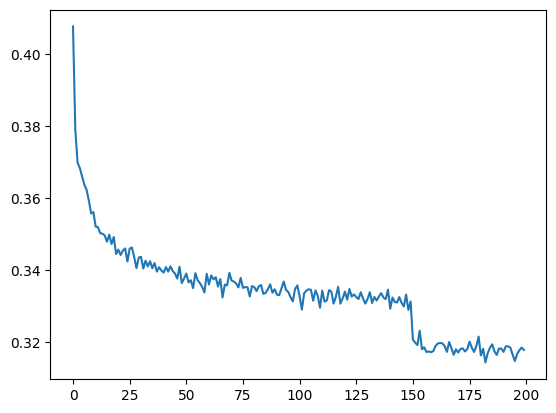

In [161]:
 plt.plot(torch.tensor(loss_vals).reshape(-1, 1000).mean(dim=1));

In [162]:
for layer in model.layers:
    layer.training = False

In [163]:
@torch.inference_mode()
def get_loss(split):
    x, y = {
        "train": (Xtr, Ytr),
        "dev": (Xdev, Ydev),
        "test": (Xte, Yte),
    }[split]
    logits = model(x)
    loss = F.cross_entropy(logits, y)
    print(split, loss.item())

get_loss("train")
get_loss("dev")

train 2.058725118637085
dev 2.1081697940826416


In [164]:
num_names = 20

for _ in range(num_names):
    context = [0] * context_size
    name = []
    while True:
        logits = model(torch.tensor([context]))
        probs = F.softmax(logits, dim=1)
        idx = torch.multinomial(probs, num_samples=1).item()
        if idx == 0:
            break
        name.append(itos[idx])
        context = context[1:] + [idx]
    print(''.join(name))

kei
salvun
teon
lyn
adelia
jnika
halle
keymailee
sawalys
willia
aya
lal
demin
core
jasmari
kashaveon
talex
yalexleigh
haiveeralyn
ker


In [165]:
context_size = 8

def build_dataset(words):
    x, y = [], []
    for word in words:
        context = [0] * context_size
        for ch in word + '.':
            idx = stoi[ch]
            x.append(context)
            y.append(idx)
            context = context[1:] + [idx]
    x = torch.tensor(x)
    y = torch.tensor(y)
    return x, y

tr_split = int(0.8 * len(words))
dev_split = int(0.9 * len(words))

Xtr, Ytr = build_dataset(words[:tr_split])
Xdev, Ydev = build_dataset(words[tr_split:dev_split])
Xte, Yte = build_dataset(words[dev_split:])

In [166]:
torch.manual_seed(42);

In [167]:
emb_dim = 10
hidden_dim = 200

model = Sequential([
    Embedding(vocab_size, emb_dim),
    Flatten(),
    Linear(emb_dim * context_size, hidden_dim, bias=False), BatchNorm1d(hidden_dim), Tanh(),
    Linear(hidden_dim, vocab_size)
])

with torch.inference_mode():
    model.layers[-1].weight *= 0.1

parameters = model.parameters()
for param in parameters:
    param.requires_grad = True

In [168]:
epochs = 200000
batch_size = 32
loss_vals = []

for epoch in range(epochs):
    idx = torch.randint(0, len(Xtr), (batch_size,))
    Xb, Yb = Xtr[idx], Ytr[idx]
    logits = model(Xb)
    loss = F.cross_entropy(logits, Yb)

    loss_vals.append(loss.log10().item())

    for param in parameters:
        param.grad = None

    loss.backward()

    lr = 0.1 if epoch < epochs * 3/4 else 0.01
    for param in parameters:
        param.data += -lr * param.grad

    if epoch % (epochs / 20) == 0:
        print(f"Epoch: {epoch:7d}/{epochs:7d} | Loss: {loss:.4f}")

Epoch:       0/ 200000 | Loss: 3.7847
Epoch:   10000/ 200000 | Loss: 2.0227
Epoch:   20000/ 200000 | Loss: 2.0045
Epoch:   30000/ 200000 | Loss: 1.7460
Epoch:   40000/ 200000 | Loss: 1.9717
Epoch:   50000/ 200000 | Loss: 1.9949
Epoch:   60000/ 200000 | Loss: 2.0298
Epoch:   70000/ 200000 | Loss: 1.9090
Epoch:   80000/ 200000 | Loss: 2.6236
Epoch:   90000/ 200000 | Loss: 1.8628
Epoch:  100000/ 200000 | Loss: 2.1360
Epoch:  110000/ 200000 | Loss: 1.8880
Epoch:  120000/ 200000 | Loss: 1.9967
Epoch:  130000/ 200000 | Loss: 2.1359
Epoch:  140000/ 200000 | Loss: 2.3116
Epoch:  150000/ 200000 | Loss: 1.9562
Epoch:  160000/ 200000 | Loss: 2.1903
Epoch:  170000/ 200000 | Loss: 1.6476
Epoch:  180000/ 200000 | Loss: 2.0732
Epoch:  190000/ 200000 | Loss: 2.0627


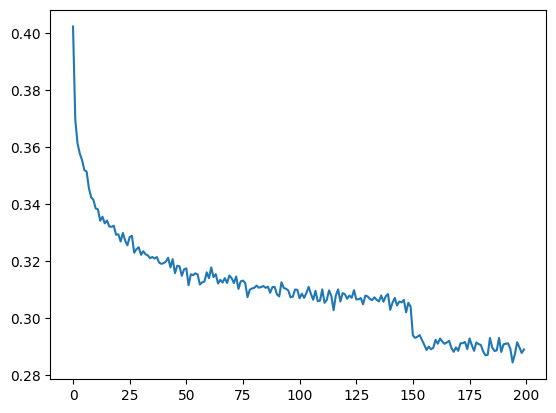

In [169]:
 plt.plot(torch.tensor(loss_vals).reshape(-1, 1000).mean(dim=1));

In [170]:
for layer in model.layers:
    layer.training = False

In [171]:
@torch.inference_mode()
def get_loss(split):
    x, y = {
        "train": (Xtr, Ytr),
        "dev": (Xdev, Ydev),
        "test": (Xte, Yte),
    }[split]
    logits = model(x)
    loss = F.cross_entropy(logits, y)
    print(split, loss.item())

get_loss("train")
get_loss("dev")

train 1.9184144735336304
dev 2.030029296875


In [172]:
num_names = 20

for _ in range(num_names):
    context = [0] * context_size
    name = []
    while True:
        logits = model(torch.tensor([context]))
        probs = F.softmax(logits, dim=1)
        idx = torch.multinomial(probs, num_samples=1).item()
        if idx == 0:
            break
        name.append(itos[idx])
        context = context[1:] + [idx]
    print(''.join(name))

kasen
kahariah
dawglyn
mckinniseus
giahlar
airington
rosaliah
aaiden
raylin
kestlar
kayzlee
ustina
azakiyah
krexleigh
aeris
treinan
kennex
finnan
andmexri
ilmannabe


In [185]:
class Linear:

    def __init__(self, in_features, out_features, bias=True):
        self.weight = torch.randn((in_features, out_features)) / in_features**0.5
        self.bias = torch.randn((out_features,)) if bias else None

    def __call__(self, x):
        self.out = x @ self.weight
        if self.bias is not None:
            self.out += self.bias
        return self.out

    def parameters(self):
        return [self.weight] + ([self.bias] if self.bias is not None else [])

class BatchNorm1d:

    def __init__(self, num_features, eps=1e-05, momentum=0.1):
        self.eps = eps
        self.momentum = momentum
        self.training = True
        self.gamma = torch.ones(num_features)
        self.beta = torch.zeros(num_features)
        self.running_mean = torch.zeros(num_features)
        self.running_var = torch.ones(num_features)

    def __call__(self, x):
        if self.training:
            xmean = x.mean(dim=0, keepdim=True)
            xvar = x.var(dim=0, keepdim=True)
        else:
            xmean = self.running_mean
            xvar = self.running_var
        xnorm = (x - xmean) / torch.sqrt(xvar + self.eps)
        self.out = self.gamma * xnorm + self.beta
        if self.training:
            with torch.inference_mode():
                self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
                self.running_var = (1 - self.momentum) * self.running_var + self.momentum * xvar
        return self.out

    def parameters(self):
        return [self.gamma, self.beta]

class Tanh:

    def __call__(self, x):
        self.out = torch.tanh(x)
        return self.out

    def parameters(self):
        return []

class Embedding:

    def __init__(self, num_embeddings, embedding_dim):
        self.weight = torch.randn((num_embeddings, embedding_dim))

    def __call__(self, idx):
        self.out = self.weight[idx]
        return self.out

    def parameters(self):
        return [self.weight]

class FlattenConsecutive:

    def __init__(self, n):
        self.n = n

    def __call__(self, x):
        B, T, C = x.shape
        x = x.reshape(B, T//self.n, C*self.n)
        if x.shape[1] == 1:
            x = x.squeeze(dim=1)
        self.out = x
        return self.out

    def parameters(self):
        return []

class Sequential:

    def __init__(self, layers):
        self.layers = layers

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        self.out = x
        return self.out

    def parameters(self):
        return [param for layer in self.layers for param in layer.parameters()]

In [190]:
emb_dim = 10
hidden_dim = 200

model = Sequential([
    Embedding(vocab_size, emb_dim),
    FlattenConsecutive(2), Linear(emb_dim * 2, hidden_dim, bias=False), BatchNorm1d(hidden_dim), Tanh(),
    FlattenConsecutive(2), Linear(hidden_dim * 2, hidden_dim, bias=False), BatchNorm1d(hidden_dim), Tanh(),
    FlattenConsecutive(2), Linear(hidden_dim * 2, hidden_dim, bias=False), BatchNorm1d(hidden_dim), Tanh(),
    Linear(hidden_dim, vocab_size)
])

with torch.inference_mode():
    model.layers[-1].weight *= 0.1

parameters = model.parameters()
for param in parameters:
    param.requires_grad = True

In [191]:
idx = torch.randint(0, len(Xtr), (4,))
Xb, Yb = Xtr[idx], Ytr[idx]
logits = model(Xb)

In [192]:
for layer in model.layers:
    print(layer.__class__.__name__, ":", tuple(layer.out.shape))

Embedding : (4, 8, 10)
FlattenConsecutive : (4, 4, 20)
Linear : (4, 4, 200)
BatchNorm1d : (4, 4, 200)
Tanh : (4, 4, 200)
FlattenConsecutive : (4, 2, 400)
Linear : (4, 2, 200)
BatchNorm1d : (4, 2, 200)
Tanh : (4, 2, 200)
FlattenConsecutive : (4, 400)
Linear : (4, 200)
BatchNorm1d : (4, 200)
Tanh : (4, 200)
Linear : (4, 27)


In [ ]:
# Ilk Flatten 8 karakteri ikiserli 4 gruba ayiriyor bu yuzden shape[1] 8 -> 4 oluyor.
# Ikinci Flatten 4 grubu ikiserli esleyip 2 gruba ayiriyor bu yuzden shape[1] 4 -> 2 oluyor.
# Son Flatten kalan 2 grubu tek birgruba topluyor bu yuzden shape[1] 2 -> 1 oluyor.

In [194]:
emb_dim = 10
hidden_dim = 68

model = Sequential([
    Embedding(vocab_size, emb_dim),
    FlattenConsecutive(2), Linear(emb_dim * 2, hidden_dim, bias=False), BatchNorm1d(hidden_dim), Tanh(),
    FlattenConsecutive(2), Linear(hidden_dim * 2, hidden_dim, bias=False), BatchNorm1d(hidden_dim), Tanh(),
    FlattenConsecutive(2), Linear(hidden_dim * 2, hidden_dim, bias=False), BatchNorm1d(hidden_dim), Tanh(),
    Linear(hidden_dim, vocab_size)
])

with torch.inference_mode():
    model.layers[-1].weight *= 0.1

parameters = model.parameters()
for param in parameters:
    param.requires_grad = True

In [195]:
epochs = 200000
batch_size = 32
loss_vals = []

for epoch in range(epochs):
    idx = torch.randint(0, len(Xtr), (batch_size,))
    Xb, Yb = Xtr[idx], Ytr[idx]
    logits = model(Xb)
    loss = F.cross_entropy(logits, Yb)

    loss_vals.append(loss.log10().item())

    for param in parameters:
        param.grad = None

    loss.backward()

    lr = 0.1 if epoch < epochs * 3/4 else 0.01
    for param in parameters:
        param.data += -lr * param.grad

    if epoch % (epochs / 20) == 0:
        print(f"Epoch: {epoch:7d}/{epochs:7d} | Loss: {loss:.4f}")

Epoch:       0/ 200000 | Loss: 3.5437
Epoch:   10000/ 200000 | Loss: 2.2196
Epoch:   20000/ 200000 | Loss: 2.4951
Epoch:   30000/ 200000 | Loss: 1.8562
Epoch:   40000/ 200000 | Loss: 2.0407
Epoch:   50000/ 200000 | Loss: 1.6141
Epoch:   60000/ 200000 | Loss: 2.0353
Epoch:   70000/ 200000 | Loss: 2.0611
Epoch:   80000/ 200000 | Loss: 2.3251
Epoch:   90000/ 200000 | Loss: 1.7239
Epoch:  100000/ 200000 | Loss: 2.7868
Epoch:  110000/ 200000 | Loss: 1.8427
Epoch:  120000/ 200000 | Loss: 2.0890
Epoch:  130000/ 200000 | Loss: 2.2255
Epoch:  140000/ 200000 | Loss: 2.2317
Epoch:  150000/ 200000 | Loss: 1.5586
Epoch:  160000/ 200000 | Loss: 1.9105
Epoch:  170000/ 200000 | Loss: 2.0321
Epoch:  180000/ 200000 | Loss: 1.9166
Epoch:  190000/ 200000 | Loss: 2.1935


In [197]:
for layer in model.layers:
    layer.training = False

In [198]:
@torch.inference_mode()
def get_loss(split):
    x, y = {
        "train": (Xtr, Ytr),
        "dev": (Xdev, Ydev),
        "test": (Xte, Yte),
    }[split]
    logits = model(x)
    loss = F.cross_entropy(logits, y)
    print(split, loss.item())

get_loss("train")
get_loss("dev")

train 1.9409053325653076
dev 2.023416042327881


In [202]:
class Linear:

    def __init__(self, in_features, out_features, bias=True):
        self.weight = torch.randn((in_features, out_features)) / in_features**0.5
        self.bias = torch.randn((out_features,)) if bias else None

    def __call__(self, x):
        self.out = x @ self.weight
        if self.bias is not None:
            self.out += self.bias
        return self.out

    def parameters(self):
        return [self.weight] + ([self.bias] if self.bias is not None else [])

class BatchNorm1d:

    def __init__(self, num_features, eps=1e-05, momentum=0.1):
        self.eps = eps
        self.momentum = momentum
        self.training = True
        self.gamma = torch.ones(num_features)
        self.beta = torch.zeros(num_features)
        self.running_mean = torch.zeros(num_features)
        self.running_var = torch.ones(num_features)

    def __call__(self, x):
        if self.training:
            if x.ndim == 2:
                dim = 0
            elif x.ndim == 3:
                dim = (0, 1)
            xmean = x.mean(dim, keepdim=True)
            xvar = x.var(dim, keepdim=True)
        else:
            xmean = self.running_mean
            xvar = self.running_var
        xnorm = (x - xmean) / torch.sqrt(xvar + self.eps)
        self.out = self.gamma * xnorm + self.beta
        if self.training:
            with torch.inference_mode():
                self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
                self.running_var = (1 - self.momentum) * self.running_var + self.momentum * xvar
        return self.out

    def parameters(self):
        return [self.gamma, self.beta]

class Tanh:

    def __call__(self, x):
        self.out = torch.tanh(x)
        return self.out

    def parameters(self):
        return []

class Embedding:

    def __init__(self, num_embeddings, embedding_dim):
        self.weight = torch.randn((num_embeddings, embedding_dim))

    def __call__(self, idx):
        self.out = self.weight[idx]
        return self.out

    def parameters(self):
        return [self.weight]

class FlattenConsecutive:

    def __init__(self, n):
        self.n = n

    def __call__(self, x):
        B, T, C = x.shape
        x = x.reshape(B, T//self.n, C*self.n)
        if x.shape[1] == 1:
            x = x.squeeze(dim=1)
        self.out = x
        return self.out

    def parameters(self):
        return []

class Sequential:

    def __init__(self, layers):
        self.layers = layers

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        self.out = x
        return self.out

    def parameters(self):
        return [param for layer in self.layers for param in layer.parameters()]

In [203]:
epochs = 200000
batch_size = 32
loss_vals = []

for epoch in range(epochs):
    idx = torch.randint(0, len(Xtr), (batch_size,))
    Xb, Yb = Xtr[idx], Ytr[idx]
    logits = model(Xb)
    loss = F.cross_entropy(logits, Yb)

    loss_vals.append(loss.log10().item())

    for param in parameters:
        param.grad = None

    loss.backward()

    lr = 0.1 if epoch < epochs * 3/4 else 0.01
    for param in parameters:
        param.data += -lr * param.grad

    if epoch % (epochs / 20) == 0:
        print(f"Epoch: {epoch:7d}/{epochs:7d} | Loss: {loss:.4f}")

Epoch:       0/ 200000 | Loss: 1.8260
Epoch:   10000/ 200000 | Loss: 2.2070
Epoch:   20000/ 200000 | Loss: 1.7747
Epoch:   30000/ 200000 | Loss: 2.1192
Epoch:   40000/ 200000 | Loss: 1.9262
Epoch:   50000/ 200000 | Loss: 2.1291
Epoch:   60000/ 200000 | Loss: 2.1420
Epoch:   70000/ 200000 | Loss: 1.8952
Epoch:   80000/ 200000 | Loss: 1.6019
Epoch:   90000/ 200000 | Loss: 1.8580
Epoch:  100000/ 200000 | Loss: 1.8694
Epoch:  110000/ 200000 | Loss: 1.9217
Epoch:  120000/ 200000 | Loss: 2.1206
Epoch:  130000/ 200000 | Loss: 1.8638
Epoch:  140000/ 200000 | Loss: 2.2184
Epoch:  150000/ 200000 | Loss: 2.0292
Epoch:  160000/ 200000 | Loss: 1.8773
Epoch:  170000/ 200000 | Loss: 1.4644
Epoch:  180000/ 200000 | Loss: 1.9153
Epoch:  190000/ 200000 | Loss: 1.7521


In [204]:
for layer in model.layers:
    layer.training = False

In [205]:
@torch.inference_mode()
def get_loss(split):
    x, y = {
        "train": (Xtr, Ytr),
        "dev": (Xdev, Ydev),
        "test": (Xte, Yte),
    }[split]
    logits = model(x)
    loss = F.cross_entropy(logits, y)
    print(split, loss.item())

get_loss("train")
get_loss("dev")

train 1.8626712560653687
dev 2.0226075649261475
